In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import PIL
import random
import seaborn as sns
import cv2
import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.models as models

from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from PIL import Image
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from tqdm import tqdm
from pathlib import Path

In [2]:
# Set random seed for reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print(f"Random seed set to {seed}")

set_seed(42)

# Set device
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Define paths
DATA_ROOT = r"D:\Uni\Lab\inebriation-voice-detector\data\processed"
TRAIN_DIR = os.path.join(DATA_ROOT, "TRAIN")
VAL_DIR = os.path.join(DATA_ROOT, "VALIDATION")
TEST_DIR = os.path.join(DATA_ROOT, "TEST")

# Create output directory
OUTPUT_ROOT = r"D:\Uni\Lab\inebriation-voice-detector\output"
OUTPUT_DIR =os.path.join(OUTPUT_ROOT, "resnet18_gokul")
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Define class labels
classes = ['SOBER', 'DRUNK']
class_to_idx = {cls: idx for idx, cls in enumerate(classes)}
idx_to_class = {idx: cls for idx, cls in enumerate(classes)}
print(idx_to_class)
print(class_to_idx)


Random seed set to 42
Using device: cuda:0
{0: 'SOBER', 1: 'DRUNK'}
{'SOBER': 0, 'DRUNK': 1}


## Data Exploration

In [3]:
def explore_dataset(data_dir, title):
    """Explore the dataset and visualize class distribution."""
    class_counts = {cls: 0 for cls in classes}
    file_paths = []
    labels = []
    
    for class_name in classes:
        class_path = os.path.join(data_dir, class_name)
        if os.path.isdir(class_path):
            files = [f for f in os.listdir(class_path) if f.endswith(('.jpg', '.png'))]
            class_counts[class_name] = len(files)
            
            for file in files:
                file_paths.append(os.path.join(class_path, file))
                labels.append(class_to_idx[class_name])
    
    # Print statistics
    print(f"\n{title} Dataset Statistics:")
    for cls, count in class_counts.items():
        print(f"  {cls}: {count} samples")
    print(f"  Total: {sum(class_counts.values())} samples")
    
    # Plot class distribution
    plt.figure(figsize=(8, 5))
    sns.barplot(x=list(class_counts.keys()), y=list(class_counts.values()))
    plt.title(f"{title} Dataset Class Distribution")
    plt.xlabel("Class")
    plt.ylabel("Number of Samples")
    for i, count in enumerate(class_counts.values()):
        plt.text(i, count + 5, str(count), ha='center')
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, f"{title.lower()}_class_distribution.png"))
    plt.close()
    
    return file_paths, labels, class_counts

# Explore all datasets
train_files, train_labels, train_counts = explore_dataset(TRAIN_DIR, "Training")
val_files, val_labels, val_counts = explore_dataset(VAL_DIR, "Validation")
test_files, test_labels, test_counts = explore_dataset(TEST_DIR, "Test")


Training Dataset Statistics:
  SOBER: 5189 samples
  DRUNK: 2281 samples
  Total: 7470 samples

Validation Dataset Statistics:
  SOBER: 3741 samples
  DRUNK: 1573 samples
  Total: 5314 samples

Test Dataset Statistics:
  SOBER: 2187 samples
  DRUNK: 1858 samples
  Total: 4045 samples


## Dataset 

In [4]:
class SpectrogramDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.classes = ['SOBER', 'DRUNK']
        self.class_to_idx = {cls: idx for idx, cls in enumerate(self.classes)}
        self.samples = self._make_dataset()
        
    def _make_dataset(self):
        samples = []
        for class_name in os.listdir(self.root_dir):
            class_path = os.path.join(self.root_dir, class_name)
            if os.path.isdir(class_path):
                class_idx = self.class_to_idx[class_name]
                for filename in os.listdir(class_path):
                    if filename.endswith(('.jpg', '.jpeg', '.png')):
                        samples.append((
                            os.path.join(class_path, filename),
                            class_idx
                        ))
        return samples
    
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        image = Image.open(img_path).convert('RGB')
        
        if self.transform:
            image = self.transform(image)
            
        return image, label, img_path


## Data Preparation

In [5]:
import timm
from timm.data import resolve_data_config
from timm.data.transforms_factory import create_transform

model = timm.create_model('vit_base_patch16_224', pretrained=True, num_classes=2)
mode = model.to(device)
config = resolve_data_config({}, model=model)
transform = create_transform(**config)


c:\Users\krevi\AppData\Local\anaconda3\envs\phonetics_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
# Initialize datasets
train_dataset = SpectrogramDataset(TRAIN_DIR, transform)
val_dataset = SpectrogramDataset(VAL_DIR, transform)
test_dataset = SpectrogramDataset(TEST_DIR, transform)

# Create balanced sampler
class_counts = torch.tensor([len([x for x in train_dataset.samples if x[1] == i]) for i in range(2)])
class_weights = 1. / class_counts
class_weights = class_weights / class_weights.sum()  # Normalize
sample_weights = torch.tensor([class_weights[y] for _, y in train_dataset.samples])
sampler = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)

# Create data loaders
BATCH_SIZE = 32
kwargs = {}
# kwargs = {'num_workers': 2, 'pin_memory': True} if torch.cuda.is_available() else {}

             
train_loader = DataLoader(
    train_dataset, 
    batch_size=BATCH_SIZE, 
    sampler=sampler,
    # shuffle=True,
    **kwargs
)

val_loader = DataLoader(
    val_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=False, 
    **kwargs
)

test_loader = DataLoader(
    test_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=False, 
    **kwargs
)


## Training Set Up

In [7]:
initial_lr = 1e-4
patience = 5
num_epochs = 10
# weight_decay = 1e-4

criterion = nn.CrossEntropyLoss()

# Optimizer for fine-tuned layers only
# optimizer = optim.SGD(model.parameters(), lr=initial_lr , momentum=0.9)
optimizer = optim.Adam(model.parameters(), lr=initial_lr)

# optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=initial_lr)
# optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=initial_lr , weight_decay=weight_decay)

# # Learning rate scheduler — Reduce on plateau (e.g., validation loss)
# scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=patience, factor=0.5)
# scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=patience, factor=0.5)


In [8]:
# Evaluation Function
def evaluate(model, data_loader):
    model.eval()
    all_preds = []
    all_labels = []
    running_loss = 0.0
    
    with torch.no_grad():
        for inputs, labels, _ in data_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item() * inputs.size(0)
            # preds = (outputs >= 0.5).float()
            preds = outputs.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    # Calculate metrics
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    
    # Calculate UAR (Unweighted Average Recall)
    cm = confusion_matrix(all_labels, all_preds)
    if cm.shape == (2, 2):  # binary classification
        tn, fp, fn, tp = cm.ravel()
        tnr = tn / (tn + fp) if (tn + fp) > 0 else 0
        tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
        uar = (tpr + tnr) / 2
    else:  # handle case when one class is missing in predictions
        uar = accuracy_score(all_labels, all_preds)  # fallback
    
    metrics = {
        'loss': running_loss / len(data_loader.dataset),
        'accuracy': accuracy_score(all_labels, all_preds),
        'uar': uar,
        'confusion_matrix': cm
    }
    
    return metrics

## Training

In [9]:
# Training Loop with Early Stopping
def train_model(model, train_loader, val_loader, num_epochs, patience):
    best_uar = 0
    no_improvement = 0
    history = {
        'train_loss': [], 'val_loss': [],
        'train_acc': [], 'val_acc': [],
        'train_uar': [], 'val_uar': []
    }
    
    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}")
        print("-" * 10)
        
        # Training phase
        model.train()
        train_loss = 0
        train_preds = []
        train_labels = []
        
        for inputs, labels,_ in tqdm(train_loader, desc="Training"):
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item() * inputs.size(0)
            # preds = (outputs >= 0.5).float()
            preds = outputs.argmax(dim=1)
            train_preds.extend(preds.cpu().numpy())
            train_labels.extend(labels.cpu().numpy())
        
        # Calculate training metrics
        train_loss = train_loss / len(train_loader.dataset)
        train_acc = accuracy_score(train_labels, train_preds)
        
        # Calculate training UAR
        train_cm = confusion_matrix(train_labels, train_preds)
        if train_cm.shape == (2, 2):
            tn, fp, fn, tp = train_cm.ravel()
            tnr = tn / (tn + fp) if (tn + fp) > 0 else 0
            tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
            train_uar = (tpr + tnr) / 2
        else:
            train_uar = train_acc
        
        # Validation phase
        val_metrics = evaluate(model, val_loader)
        
        # Update LR scheduler
        # scheduler.step()
        # scheduler.step(val_metrics['loss'])
        
        # Save history
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_metrics['loss'])
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_metrics['accuracy'])
        history['train_uar'].append(train_uar)
        history['val_uar'].append(val_metrics['uar'])
        
        # Print metrics
        print(f"Train Loss: {train_loss:.4f} | Val Loss: {val_metrics['loss']:.4f}")
        print(f"Train Acc: {train_acc:.4f} | Val Acc: {val_metrics['accuracy']:.4f}")
        print(f"Train UAR: {train_uar:.4f} | Val UAR: {val_metrics['uar']:.4f}")
        print("Validation Confusion Matrix:")
        print(val_metrics['confusion_matrix'])
        
        # Early stopping check
        if val_metrics['uar'] > best_uar:
            best_uar = val_metrics['uar']
            no_improvement = 0
            torch.save(model.state_dict(), os.path.join(OUTPUT_DIR,"best_model.pth"))
            print("Saved new best model (based on UAR)!")
        else:
            no_improvement += 1
            print(f"No improvement in UAR for {no_improvement}/{patience} epochs")
            
            if no_improvement >= patience:
                print(f"\nEarly stopping triggered after {patience} epochs without improvement!")
                break
    
    # Load the best model weights before returning
    model.load_state_dict(torch.load(os.path.join(OUTPUT_DIR,"best_model.pth")) )
    print("\nTraining completed. Loaded best model weights.")
    
    return history

# Train the model with early stopping
history = train_model(
    model, 
    train_loader, 
    val_loader, 
    num_epochs,
    patience  # Stop if no improvement for 10 epochs
)



Epoch 1/10
----------


Training: 100%|██████████| 234/234 [01:58<00:00,  1.98it/s]


Train Loss: 0.7282 | Val Loss: 0.7891
Train Acc: 0.5209 | Val Acc: 0.3387
Train UAR: 0.5208 | Val UAR: 0.5165
Validation Confusion Matrix:
[[ 302 3439]
 [  75 1498]]
Saved new best model (based on UAR)!

Epoch 2/10
----------


Training: 100%|██████████| 234/234 [01:58<00:00,  1.98it/s]


Train Loss: 0.6790 | Val Loss: 0.6206
Train Acc: 0.5754 | Val Acc: 0.6805
Train UAR: 0.5747 | Val UAR: 0.5153
Validation Confusion Matrix:
[[3442  299]
 [1399  174]]
No improvement in UAR for 1/5 epochs

Epoch 3/10
----------


...

Train Loss: 0.2291 | Val Loss: 1.3300
Train Acc: 0.9157 | Val Acc: 0.5719
Train UAR: 0.9157 | Val UAR: 0.5336
Validation Confusion Matrix:
[[2347 1394]
 [ 881  692]]
No improvement in UAR for 3/5 epochs

Epoch 9/10
----------


Training: 100%|██████████| 234/234 [02:06<00:00,  1.85it/s]


Train Loss: 0.1665 | Val Loss: 1.4445
Train Acc: 0.9391 | Val Acc: 0.6014
Train UAR: 0.9392 | Val UAR: 0.5248
Validation Confusion Matrix:
[[2666 1075]
 [1043  530]]
No improvement in UAR for 4/5 epochs

Epoch 10/10
----------


Training: 100%|██████████| 234/234 [02:01<00:00,  1.92it/s]


Train Loss: 0.1254 | Val Loss: 1.4104
Train Acc: 0.9539 | Val Acc: 0.5948
Train UAR: 0.9540 | Val UAR: 0.5308
Validation Confusion Matrix:
[[2573 1168]
 [ 985  588]]
No improvement in UAR for 5/5 epochs

Early stopping triggered after 5 epochs without improvement!

Training completed. Loaded best model weights.


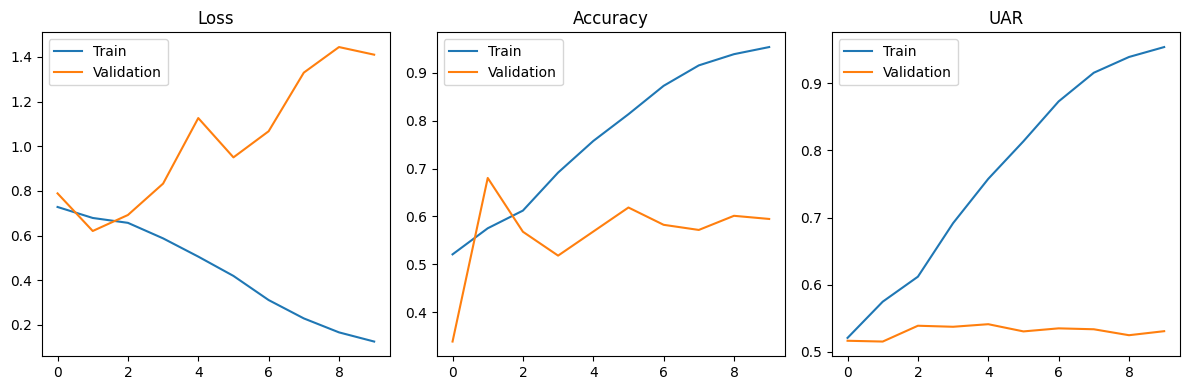

In [10]:
# Plot training curves
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.plot(history['train_loss'], label='Train')
plt.plot(history['val_loss'], label='Validation')
plt.title('Loss')
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(history['train_acc'], label='Train')
plt.plot(history['val_acc'], label='Validation')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(history['train_uar'], label='Train')
plt.plot(history['val_uar'], label='Validation')
plt.title('UAR')
plt.legend()

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR,"training_curves.png"))
plt.show()


## Evaluation


Final Test Results:
Accuracy: 0.5795
UAR: 0.5749
Confusion Matrix:
[[1381  806]
 [ 895  963]]


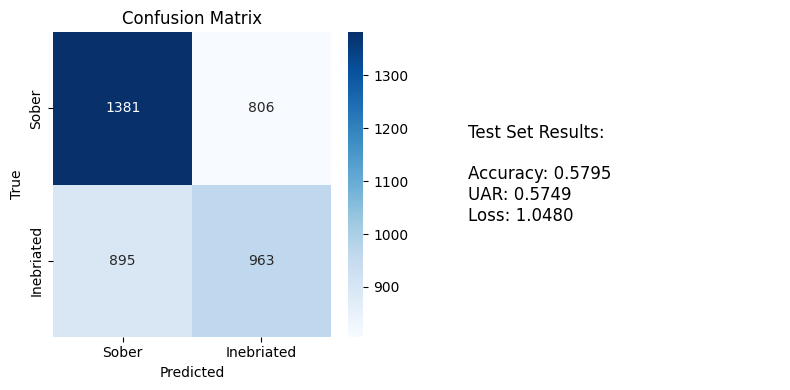

In [11]:
def plot_results(metrics, class_names):
    plt.figure(figsize=(8, 4))
    
    # Confusion matrix
    plt.subplot(1, 2, 1)
    sns.heatmap(metrics['confusion_matrix'], annot=True, fmt='d', 
                cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    
    # Metrics summary
    plt.subplot(1, 2, 2)
    plt.axis('off')
    metrics_text = (
        "Test Set Results:\n\n"
        f"Accuracy: {metrics['accuracy']:.4f}\n"
        f"UAR: {metrics['uar']:.4f}\n"
        f"Loss: {metrics['loss']:.4f}\n"
    )
    plt.text(0.1, 0.5, metrics_text, fontsize=12, va='center')
    
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR,"test_results.png"))
    plt.show()

def get_detailed_predictions(model, data_loader, device='cuda'):
    model.eval()
    all_preds, all_labels, all_probs = [], [], []
    all_filenames = []

    with torch.no_grad():
        for inputs, labels, paths in data_loader:  # assuming custom dataset returns file paths too
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            probs = torch.softmax(outputs, dim=1)
            preds = probs.argmax(dim=1)
            # preds = (probs >= 0.5).float()

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
            all_filenames.extend([os.path.basename(p) for p in paths])
            # break
            
    probs_np = np.array(all_probs)
    return pd.DataFrame({
        'filename': all_filenames,
        'true_label': all_labels,
        'predicted_label': all_preds,
        'prob_drunk': probs_np[:, 1],
        'prob_sober': probs_np[:, 0],
        'correct': np.array(all_preds) == np.array(all_labels)
    })
     

# Load model and evaluate metrics
model.load_state_dict(torch.load(os.path.join(OUTPUT_DIR, "best_model.pth")))
test_metrics = evaluate(model, test_loader)

print("\nFinal Test Results:")
print(f"Accuracy: {test_metrics['accuracy']:.4f}")
print(f"UAR: {test_metrics['uar']:.4f}")
print("Confusion Matrix:")
print(test_metrics['confusion_matrix'])
plot_results(test_metrics, ['Sober', 'Inebriated'])

# Get per-sample predictions
df_preds = get_detailed_predictions(model, test_loader,device='cuda')
df_preds.to_csv(os.path.join(OUTPUT_DIR, "detailed_predictions.csv"), index=False)



In [12]:
df_preds.to_csv(os.path.join(OUTPUT_DIR, "detailed_predictions.csv"), index=False)

### Post processing error analysis

c:\Users\krevi\AppData\Local\anaconda3\envs\phonetics_env\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\krevi\AppData\Local\anaconda3\envs\phonetics_env\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\krevi\AppData\Local\anaconda3\envs\phonetics_env\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metr

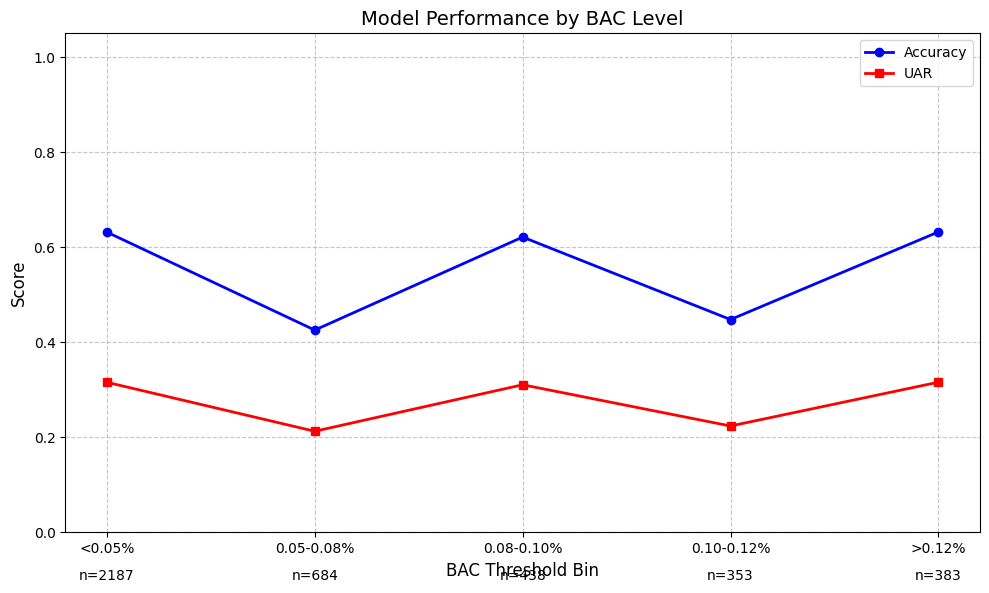

      BAC_bin  Accuracy       UAR  Count  bin_code
0      <0.05%  0.631459  0.315729   2187         0
1  0.05-0.08%  0.425439  0.212719    684         1
2  0.08-0.10%  0.621005  0.310502    438         2
3  0.10-0.12%  0.447592  0.223796    353         3
4      >0.12%  0.631854  0.315927    383         4


In [13]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import recall_score


def analyze_performance_by_bac(preds_path, metadata_path):
    # Load and merge data
    preds = pd.read_csv(preds_path)
    meta = pd.read_csv(metadata_path)
    
    # Clean filenames
    preds['filename'] = preds['filename'].apply(lambda x: x.split('/')[-1])
    meta['filename'] = meta['spectrogram_fileP'].apply(lambda x: x.split('\\')[-1])
    
    # Merge datasets on cleaned filename
    df = pd.merge(preds, meta[['filename', 'BAC_level']], on='filename', how='inner')
    
    # Define BAC bins and labels
    bins = [0, 0.0005, 0.0008, 0.0010, 0.0012, float('inf')]
    labels = ['<0.05%', '0.05-0.08%', '0.08-0.10%', '0.10-0.12%', '>0.12%']
    df['BAC_bin'] = pd.cut(df['BAC_level'], bins=bins, labels=labels, right=False)
    
    # Prepare results in order of labels
    results = []
    for bin_name in labels:
        group = df[df['BAC_bin'] == bin_name]
        if len(group) == 0:
            acc = float('nan')
            uar = float('nan')
        else:
            acc = group['correct'].mean()
            uar = recall_score(group['true_label'], group['predicted_label'], average='macro')
        results.append({
            'BAC_bin': bin_name,
            'Accuracy': acc,
            'UAR': uar,
            'Count': len(group)
        })
    
    metrics_df = pd.DataFrame(results)
    
    # Add numeric code for x-axis plotting
    metrics_df['bin_code'] = range(len(metrics_df))
    
    # Plot performance
    plt.figure(figsize=(10, 6))
    plt.plot(metrics_df['bin_code'], metrics_df['Accuracy'], 
             marker='o', label='Accuracy', color='blue', linewidth=2)
    plt.plot(metrics_df['bin_code'], metrics_df['UAR'], 
             marker='s', label='UAR', color='red', linewidth=2)
    
    plt.xticks(metrics_df['bin_code'], metrics_df['BAC_bin'])
    plt.title('Model Performance by BAC Level', fontsize=14)
    plt.xlabel('BAC Threshold Bin', fontsize=12)
    plt.ylabel('Score', fontsize=12)
    plt.ylim(0, 1.05)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()
    
    # Add sample count below x-axis
    for i, row in metrics_df.iterrows():
        plt.text(row['bin_code'], -0.1, f"n={row['Count']}", ha='center', fontsize=10)
    
    plt.tight_layout()
    
    # Create output directory if not exists
    if not os.path.exists(OUTPUT_DIR):
        os.makedirs(OUTPUT_DIR)
    plt.savefig(os.path.join(OUTPUT_DIR, "uar_bac_thresholds.png"))
    plt.show()
    
    return metrics_df

preds_path = os.path.join(OUTPUT_DIR, "detailed_predictions.csv")
metadata_path = r"D:\Uni\Lab\inebriation-voice-detector\data\metadata\spectrogram_listTest.csv"
results = analyze_performance_by_bac(preds_path, metadata_path)
print(results)


In [14]:
def analyze_uar_by_bac(preds_path, metadata_path):
    # Load and merge data
    df = pd.merge(
        pd.read_csv(preds_path).assign(filename=lambda x: x['filename'].str.split('/').str[-1]),
        pd.read_csv(metadata_path).assign(filename=lambda x: x['spectrogram_fileP'].str.split('\\').str[-1]),
        on='filename'
    )
    
    # Merge sparse bins (adjust thresholds as needed)
    df['BAC_bin'] = pd.cut(df['BAC_level'], 
                           bins=[0, 0.0005, 0.0010, float('inf')], 
                           labels=['<0.05%', '0.05-0.10%', '>0.10%'])
    
    # Overall UAR
    print(f"Overall UAR: {recall_score(df['true_label'], df['predicted_label'], average='macro'):.4f}")
    
    # Per-bin UAR with stratification
    results = []
    for bin_name in df['BAC_bin'].cat.categories:
        group = df[df['BAC_bin'] == bin_name]
        if len(group) == 0:
            continue
        cm = confusion_matrix(group['true_label'], group['predicted_label'])
        uar = recall_score(group['true_label'], group['predicted_label'], average='macro')
        results.append({
            'BAC_bin': bin_name,
            'UAR': uar,
            'Count': len(group),
            'Sober': (group['true_label'] == 0).sum(),
            'Drunk': (group['true_label'] == 1).sum(),
            'Confusion_Matrix': cm
        })
    
    metrics_df = pd.DataFrame(results)
    print(metrics_df.drop(columns=['Confusion_Matrix']))
    return metrics_df

preds_path = os.path.join(OUTPUT_DIR, "detailed_predictions.csv")
metadata_path = r"D:\Uni\Lab\inebriation-voice-detector\data\metadata\spectrogram_listTest.csv"

results = analyze_uar_by_bac(preds_path, metadata_path)
print(results)

Overall UAR: 0.5749
      BAC_bin       UAR  Count  Sober  Drunk
0      <0.05%  0.263636    165    165      0
1  0.05-0.10%  0.257353   1156      0   1156
2      >0.10%  0.262108    702      0    702
      BAC_bin       UAR  Count  Sober  Drunk      Confusion_Matrix
0      <0.05%  0.263636    165    165      0    [[87, 78], [0, 0]]
1  0.05-0.10%  0.257353   1156      0   1156  [[0, 0], [561, 595]]
2      >0.10%  0.262108    702      0    702  [[0, 0], [334, 368]]


c:\Users\krevi\AppData\Local\anaconda3\envs\phonetics_env\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\krevi\AppData\Local\anaconda3\envs\phonetics_env\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\krevi\AppData\Local\anaconda3\envs\phonetics_env\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metr